# Efficient VLM Data Loading with Ray Data and Kornia-RS

**Author:** Sai Vinay Bhoomireddy

In this tutorial, we demonstrate how to build a high-performance image loading pipeline for Vision-Language Models (VLMs) like LLaVA or Qwen-VL. 

Efficient data loading is critical for VLM training. We leverage:
* **Ray Data:** For scalable streaming of large datasets from Hugging Face.
* **kornia-rs:** For blazing fast, Rust-based image decoding and resizing.
* **PyTorch:** For final tensor collation.

By performing image decoding and resizing in Rust (before converting to PyTorch Tensors), we significantly reduce overhead and memory usage.

In [59]:
# Install required dependencies
# Note: You may need to restart the kernel after installing
# Note: We use quotes 'ray[data]' to prevent Zsh shell errors
%pip install 'ray[data]' kornia_rs torch numpy requests datasets matplotlib pydantic

Note: you may need to restart the kernel to use updated packages.


In [60]:
import io
import itertools

import kornia.image
import kornia.utils
import kornia_rs
import matplotlib.pyplot as plt
import numpy as np
import ray
import requests
import torch
from datasets import load_dataset

# Configuration
DATASET_NAME = "liuhaotian/LLaVA-Instruct-150K"
TARGET_SIZE = (336, 336)  # Standard size for models like LLaVA / SigLIP
BATCH_SIZE = 4

In [61]:
def process_batch_rust(batch: dict) -> dict:
    """
    Decodes and resizes images using the Kornia-RS Rust backend for high performance.
    Formats data for model input.
    """
    processed_images = []

    for filename in batch["image_filename"]:
        try:
            # 1. Fetch Image Bytes
            url = f"http://images.cocodataset.org/train2017/{filename}"
            response = requests.get(url, timeout=5)
            if response.status_code != 200:
                raise ValueError(f"Status: {response.status_code}")

            # 2. Decode & Resize (Rust Backend)
            # kornia_rs provides accelerated JPEG decoding (in RGB) and resizing
            decoded_img = kornia_rs.decode_image_jpeg(response.content)
            resized_img = kornia_rs.resize(decoded_img, TARGET_SIZE, interpolation="bilinear")

            # 3. Format for Model (HWC -> CHW)
            # Transpose from Height-Width-Channel to Channel-Height-Width
            final_array = resized_img.transpose(2, 0, 1)
            processed_images.append(final_array)

        except Exception:
            # Fallback: Return a black image if download or processing fails
            processed_images.append(np.zeros((3, *TARGET_SIZE), dtype=np.uint8))

    batch["pixel_values"] = processed_images
    return batch

In [62]:
def stream_hf_dataset():
    """
    Custom generator to stream the dataset safely.

    Reason: The 'id' column in this dataset sometimes mixes Integers and Strings.
    Ray's Arrow schema inference is strict and may crash if it infers 'int64'
    but encounters a string later. We force conversion to ensure stability.
    """
    # Stream from Hugging Face
    dataset = load_dataset(DATASET_NAME, split="train", streaming=True)

    for row in dataset:
        yield {
            "id": str(row["id"]),  # Force ID to string to prevent schema crashes
            "image_filename": row["image"],
            "conversations": row["conversations"],
        }

In [63]:
# 1. Initialize Ray
if not ray.is_initialized():
    ray.init(ignore_reinit_error=True)

# 2. Create Dataset (The Robust Way)
print("Streaming data from Hugging Face...")

# OPTION A:
# Manually grab 16 items from the generator using Python
# This ensures the tutorial runs
# instantly and doesn't overload your network/memory.
data_subset = list(itertools.islice(stream_hf_dataset(), 16))


# OPTION B:
# To process the entire 150k+ dataset in parallel, use 'from_generator'.
# This enables "True Streaming" (lazy loading), so it never uses
# more RAM than needed, even for terabytes of data.

# ds = ray.data.from_generator(stream_hf_dataset)


# Create the Ray Dataset from the list
ds = ray.data.from_items(data_subset)

# 3. Apply the Rust Transformation
print("Running kornia-rs transformations...")
processed_ds = ds.map_batches(process_batch_rust, batch_size=BATCH_SIZE)

Streaming data from Hugging Face...
Running kornia-rs transformations...


2026-01-11 18:29:36,118	INFO streaming_executor.py:304 -- ✔️  Dataset dataset_27_0 execution finished in 170.58 seconds
2026-01-11 18:29:36,120	INFO logging.py:397 -- Registered dataset logger for dataset dataset_30_0
2026-01-11 18:29:36,123	INFO streaming_executor.py:178 -- Starting execution of Dataset dataset_30_0. Full logs are in /tmp/ray/session_2026-01-11_11-03-33_427313_40777/logs/ray-data
2026-01-11 18:29:36,123	INFO streaming_executor.py:179 -- Execution plan of Dataset dataset_30_0: InputDataBuffer[Input] -> TaskPoolMapOperator[MapBatches(process_batch_rust)->Project]
2026-01-11 18:29:36,138	INFO progress_bar.py:213 -- === Ray Data Progress {MapBatches(process_batch_rust)->Project} ===
2026-01-11 18:29:36,139	INFO progress_bar.py:215 -- MapBatches(process_batch_rust)->Project: Tasks: 2 [backpressured:tasks]; Actors: 0; Queued blocks: 8 (0.0B); Resources: 2.0 CPU, 768.0MiB object store: Progress Completed 0 / ?
2026-01-11 18:29:36,141	INFO progress_bar.py:213 -- === Ray Data 

Consuming data with iter_torch_batches...


2026-01-11 18:29:41,189	INFO progress_bar.py:215 -- MapBatches(process_batch_rust)->Project: Tasks: 2 [backpressured:tasks]; Actors: 0; Queued blocks: 8 (0.0B); Resources: 2.0 CPU, 768.0MiB object store: Progress Completed 0 / ?
2026-01-11 18:29:41,190	INFO progress_bar.py:215 -- Running Dataset: dataset_30_0. Active & requested resources: 2/10 CPU, 768.0MiB/1.0GiB object store: Progress Completed 0 / ?
2026-01-11 18:29:46,258	INFO progress_bar.py:215 -- MapBatches(process_batch_rust)->Project: Tasks: 2; Actors: 0; Queued blocks: 0 (0.0B); Resources: 2.0 CPU, 2.6MiB object store: Progress Completed 8 / 16
2026-01-11 18:29:46,259	INFO progress_bar.py:215 -- Running Dataset: dataset_30_0. Active & requested resources: 2/10 CPU, 2.6MiB/1.0GiB object store: Progress Completed 8 / 16



Batch Tensor Shape: torch.Size([4, 3, 336, 336])
   Dtype: torch.uint8


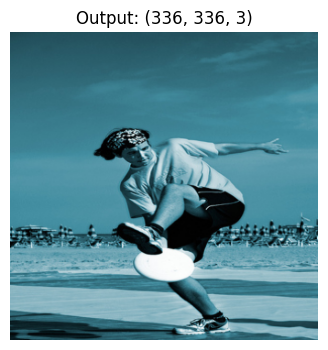

In [64]:
print("Consuming data with iter_torch_batches...")

# We select only the image column for the Tensor batch
image_ds = processed_ds.select_columns(["pixel_values"])

# iter_torch_batches automatically collates the Numpy arrays into Torch Tensors
for batch in image_ds.iter_torch_batches(batch_size=4):
    imgs = batch["pixel_values"]

    print(f"\nBatch Tensor Shape: {imgs.shape}")
    print(f"   Dtype: {imgs.dtype}")

    # Visualize the first image in the batch
    # This converts (C, H, W) tensor -> (H, W, C) numpy array automatically
    img_vis = kornia.utils.tensor_to_image(imgs[0])

    plt.figure(figsize=(4, 4))
    plt.imshow(img_vis)
    plt.title(f"Output: {img_vis.shape}")
    plt.axis("off")
    plt.show()

    break  # Only show one batch